In [1]:
# importaçaoes
import pandas as pd 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [2]:
# carregando dados 
balance_path = os.path.join('..','data', 'processed', 'balance.csv')
bureau_path = os.path.join('..','data', 'processed', 'bureau.csv')
customer_path = os.path.join('..','data', 'processed', 'customers_hist.csv')
df_balance = pd.read_csv(balance_path)
df_bureau = pd.read_csv(bureau_path)
df_customers = pd.read_csv(customer_path)

In [3]:
#funçoes auxiliares
class plot_groupby():
    def __init__(self, data:pd.DataFrame, col1:str, col2:str, title:str):
        """"title: na média estara, por exemplo, média entre ....", voce completa"""
        self.data = data
        self.col1 = col1
        self.col2 = col2
        self.title = title
    def plot_mean(self):
        group = self.data.groupby(self.col1)[self.col2].mean()
        
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20,10))
        axes[0].set_title(f'Média entre {self.title}')
        sns.barplot(group, palette='pastel', ax=axes[0])
        axes[0].tick_params(axis='x', rotation=90)
        
        group2 = self.data.groupby(self.col1)[self.col2].sum()
        axes[1].set_title(f'Valores totais {self.title}')
        sns.barplot(group2, palette='pastel', ax=axes[1])
        axes[1].tick_params(axis='x', rotation=90)

        fig.tight_layout()
        fig.show()
        
        print(f'desvio padrao: {group.std()}')
        print(f'mediana: {group.median()}')
        print(group)
    def agg_groupby(self, aggCol:str):
        group = self.data.groupby([f'{self.col1}', f'{self.col2}'])[aggCol].count()
        print(group)
        
# funcao para plot de grafico hue
def hue_plot(data:pd.DataFrame,col1:str,col2:str, hue:str, title:str):
    try:
        plt.figure(figsize=(20,10))
        plt.title(f'{title}')
        sns.barplot(data=data, x=col1, y=col2,  hue=hue, palette='pastel')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()
    except ValueError as e:
        return {f'{e}'}
    
# funçao para plot de histograma com hue 
def hist_plot(data: pd.DataFrame, hue:str):
    fig, axes = plt.subplots(ncols=2, nrows=len(data.columns), figsize=(20,25))
    for i, num in enumerate(data.columns):
        sns.histplot(ax=axes[i,0], data=data, x=num, hue=hue)
        sns.boxplot(ax=axes[i,1], data=data, x=num, hue=hue)
        axes[i,0].set_title(f'Histograma - {num}x{hue}')
        axes[i,1].set_title(f'Boxplot - {num}x{hue}')
    fig.tight_layout()
    fig.show()
        



# Bureau Balance

In [4]:
df_balance.groupby('MONTHS_BALANCE')['STATUS']

In [5]:
#verificando dados nulos 
df_balance.isnull().sum()

SK_ID_BUREAU      0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

In [6]:
df_balance['STATUS'].value_counts()

STATUS
C    7238
X    4063
0    3604
1      83
2      10
3       2
Name: count, dtype: int64

In [7]:
# verificando id's repetidos 
df_balance['SK_ID_BUREAU'].duplicated().value_counts()

SK_ID_BUREAU
True     14622
False      378
Name: count, dtype: int64

In [8]:
# aplicando multiplicaçao por -1 para tirar fator negativo nos atrasos 
df_balance['MONTHS_BALANCE'] = df_balance['MONTHS_BALANCE']*-1

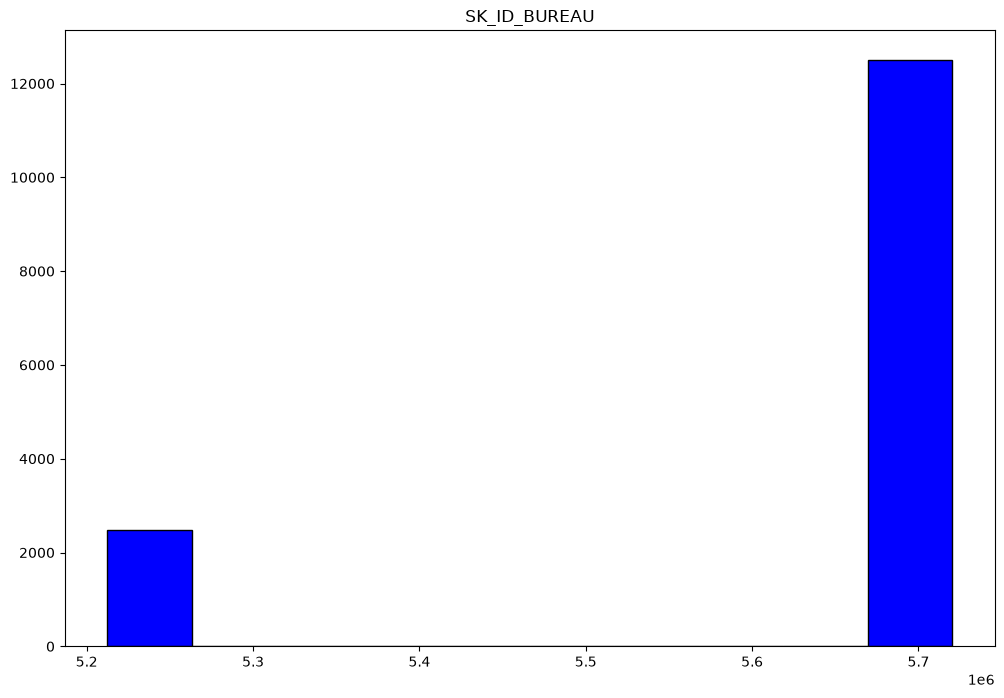

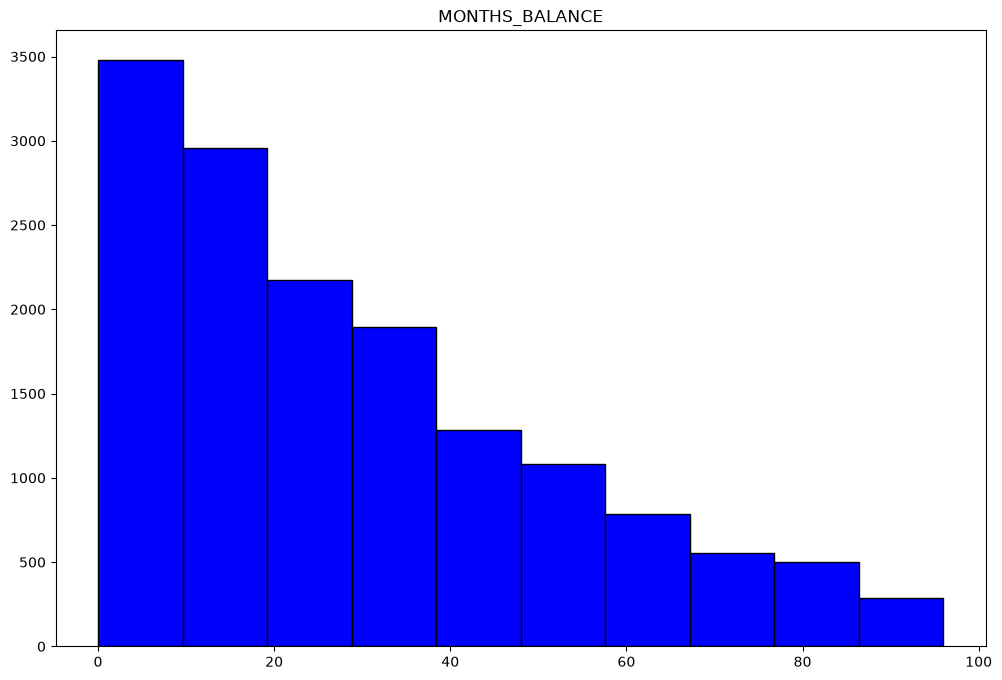

In [9]:
num_col_balance = df_balance.select_dtypes(include='number')
for num_bal in num_col_balance:
    plt.figure(figsize=(12,8))
    plt.title(f'{num_bal}')
    plt.hist(df_balance[num_bal], color='blue', edgecolor='black')
    plt.show()

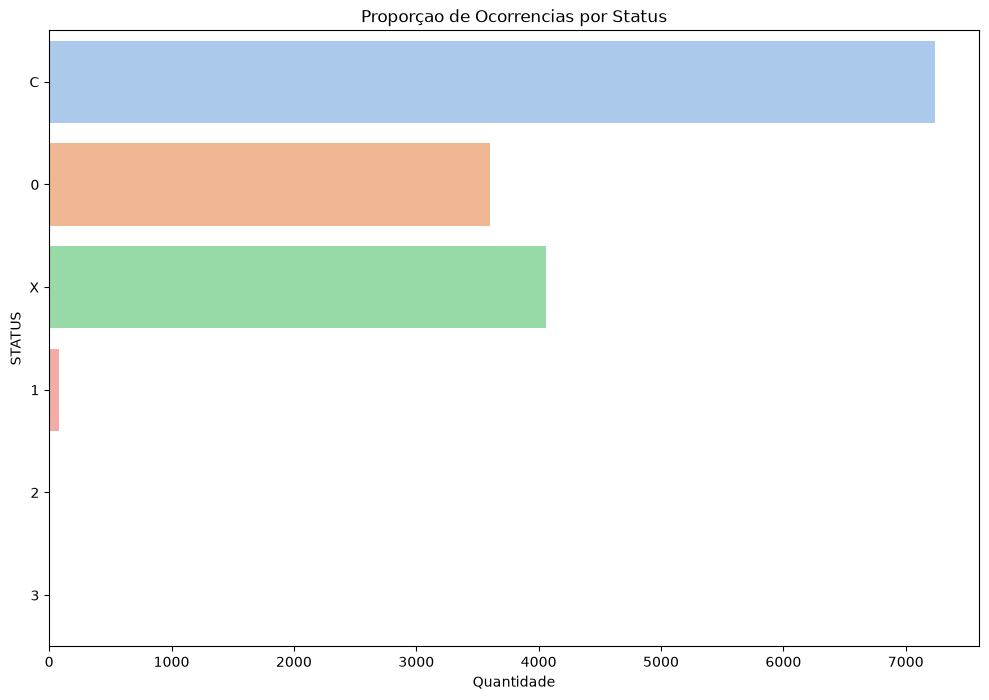

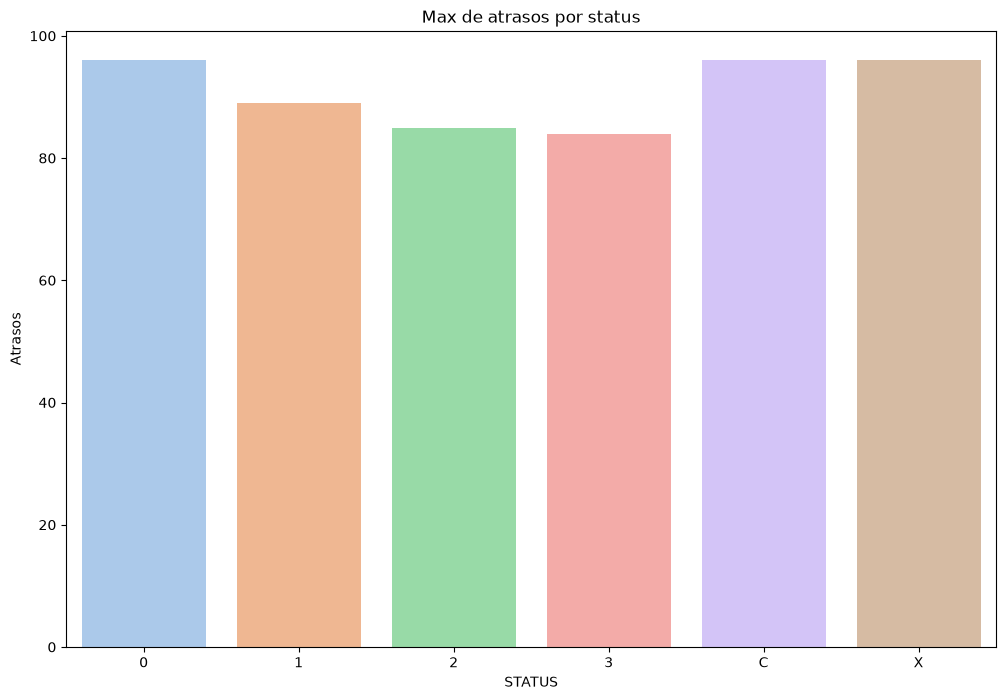

In [10]:
# filtrando id's com maior atraso e avaliando reputaçao 
filter = df_balance.groupby('STATUS')[['MONTHS_BALANCE']].max()

# plotando quantidade de ocorrencias por status
plt.figure(figsize=(12,8))
plt.title('Proporçao de Ocorrencias por Status')
sns.countplot(data=df_balance, y='STATUS', palette='pastel')
plt.xlabel('Quantidade')
plt.show()

# plotando filtro de maiores atrasos por status 
plt.figure(figsize=(12,8))
plt.title('Max de atrasos por status')
sns.barplot(data=filter, x='STATUS', y='MONTHS_BALANCE', palette='pastel')
plt.ylabel('Atrasos')
plt.show()


# Bureau 

In [11]:
df_bureau

,CONTAS_ATIVAS,MEDIA_ATRASO_DIAS,CREDIT_TYPE,CREDIT_ACTIVE
0,1,187,Another type of loan,Active
1,1,1007,Real estate loan,Active
2,1,986,Credit card,Bad debt
3,1,308,Loan for working capital replenishment,Closed
4,2,2661,Unknown type of loan,Closed
5,3,1463,Car loan,Sold
6,4,133,Loan for working capital replenishment,Active
7,4,1463,Mortgage,Sold
8,5,541,Another type of loan,Closed
9,8,2827,Loan for business development,Closed


desvio padrao: 1127.4725839101968
mediana: 33.33333333333333
CREDIT_TYPE
Another type of loan                         3.000000
Car loan                                    77.666667
Consumer credit                           3582.333333
Credit card                                912.000000
Loan for business development                8.000000
Loan for working capital replenishment       2.500000
Microloan                                   87.000000
Mortgage                                    58.666667
Real estate loan                             1.000000
Unknown type of loan                         2.000000
Name: CONTAS_ATIVAS, dtype: float64


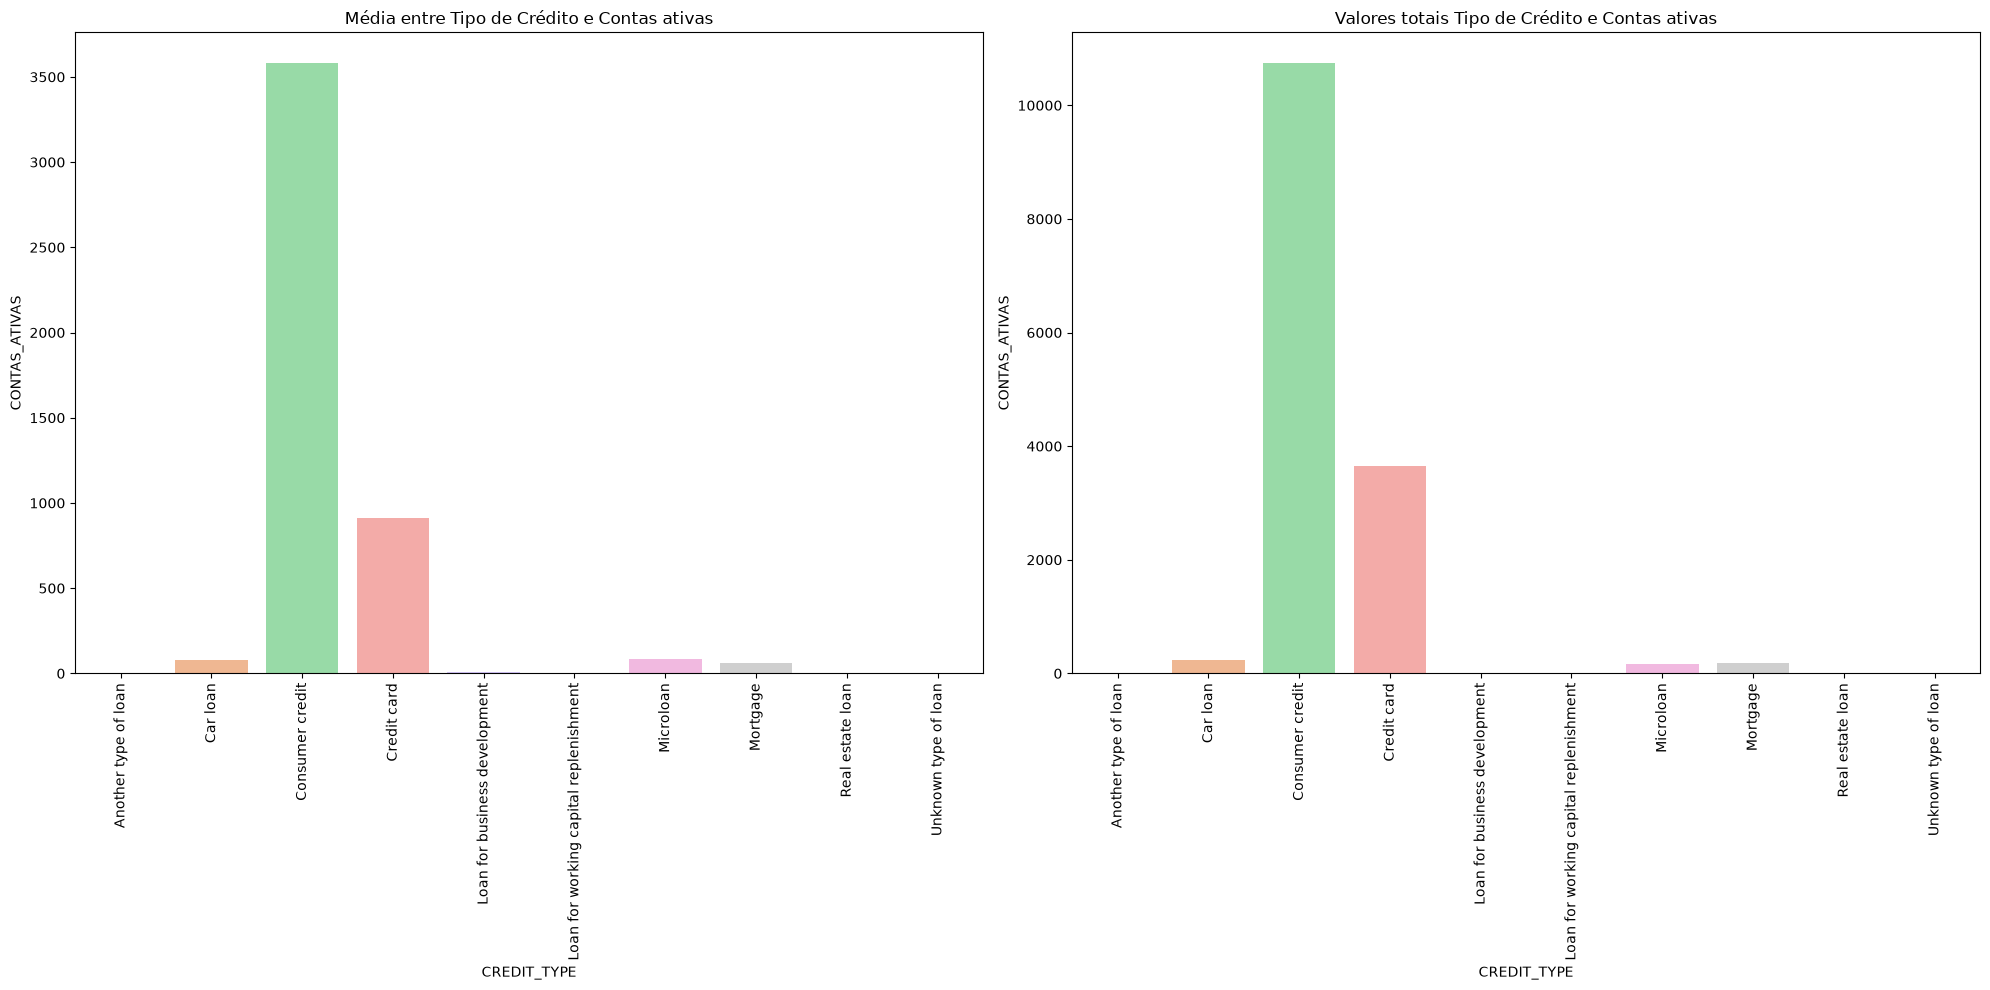

In [12]:
plot_groupby(df_bureau, 'CREDIT_TYPE', 'CONTAS_ATIVAS', 'Tipo de Crédito e Contas ativas').plot_mean()

desvio padrao: 940.017925730379
mediana: 948.375
CREDIT_TYPE
Another type of loan                       364.00
Car loan                                  1472.00
Consumer credit                            673.00
Credit card                                889.75
Loan for business development             2827.00
Loan for working capital replenishment     220.50
Microloan                                  188.00
Mortgage                                  1330.00
Real estate loan                          1007.00
Unknown type of loan                      2661.00
Name: MEDIA_ATRASO_DIAS, dtype: float64


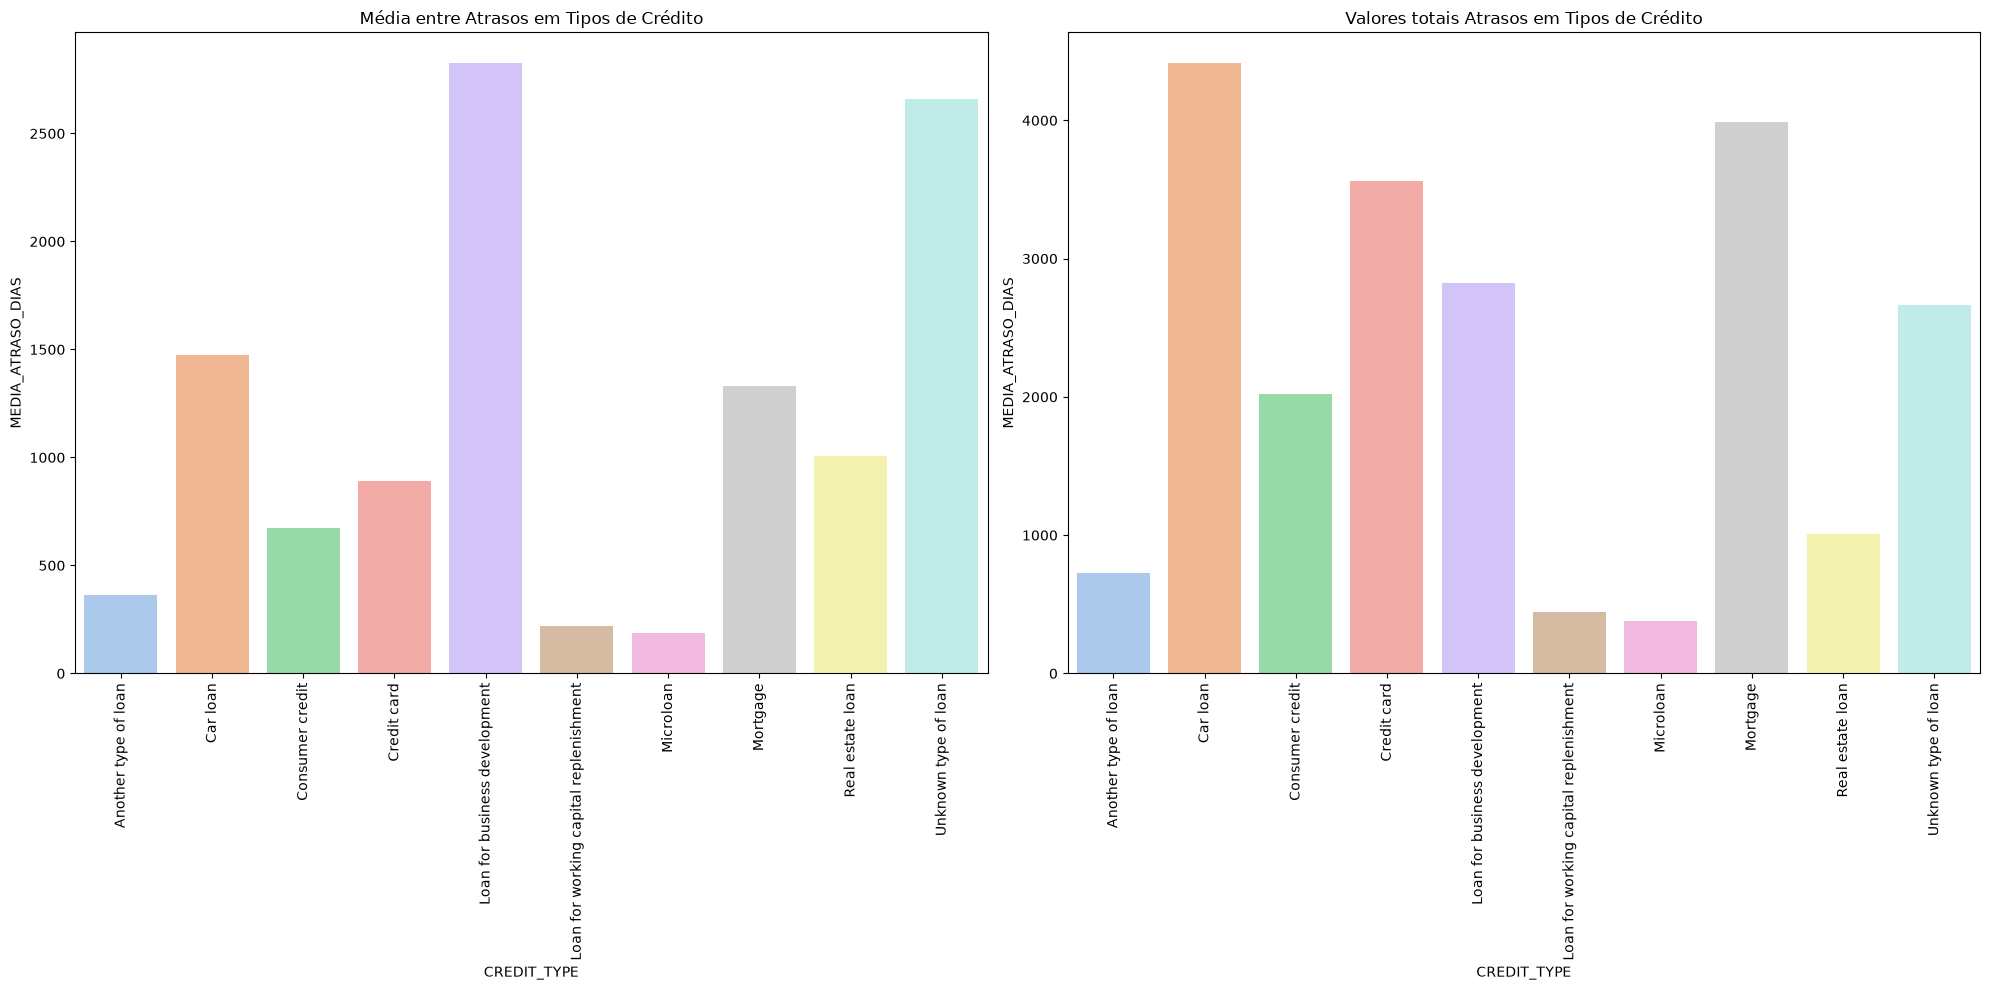

In [13]:
plot_groupby(df_bureau, 'CREDIT_TYPE', 'MEDIA_ATRASO_DIAS', 'Atrasos em Tipos de Crédito').plot_mean()

In [14]:
df_bureau

,CONTAS_ATIVAS,MEDIA_ATRASO_DIAS,CREDIT_TYPE,CREDIT_ACTIVE
0,1,187,Another type of loan,Active
1,1,1007,Real estate loan,Active
2,1,986,Credit card,Bad debt
3,1,308,Loan for working capital replenishment,Closed
4,2,2661,Unknown type of loan,Closed
5,3,1463,Car loan,Sold
6,4,133,Loan for working capital replenishment,Active
7,4,1463,Mortgage,Sold
8,5,541,Another type of loan,Closed
9,8,2827,Loan for business development,Closed


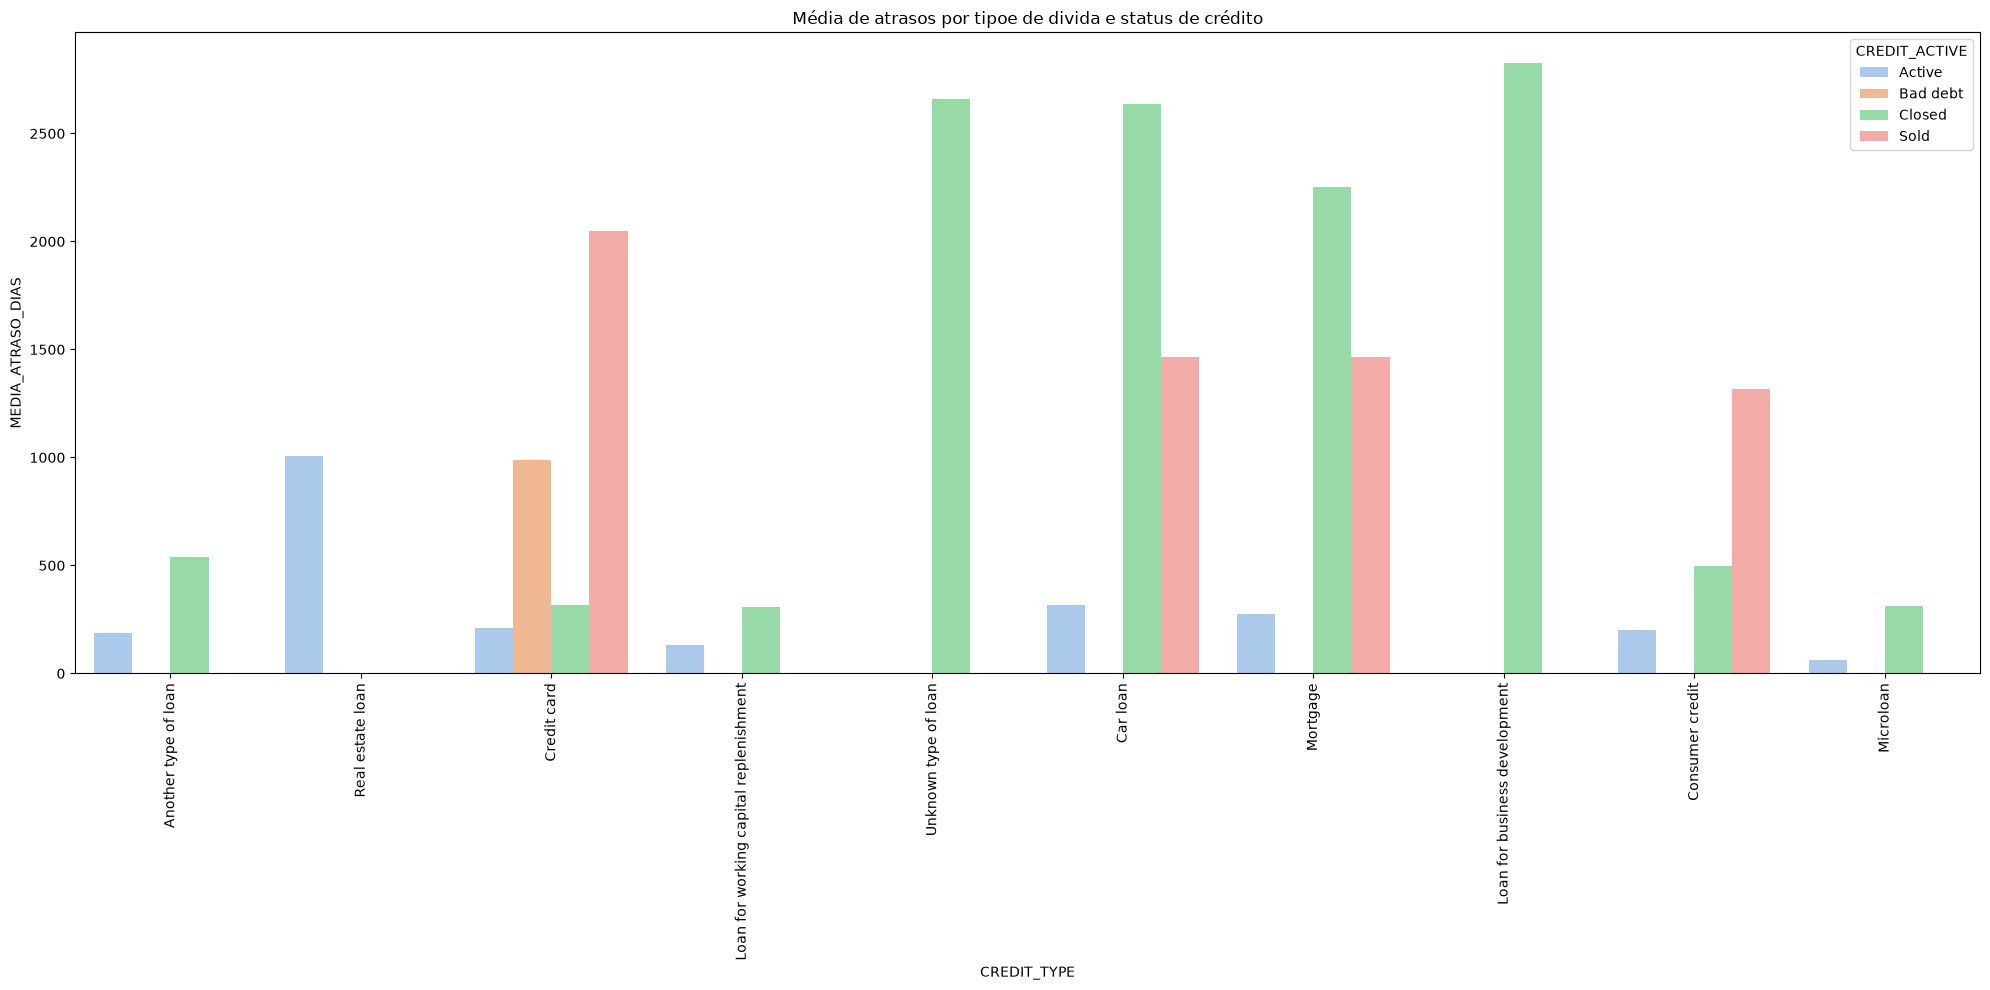

In [15]:
# plotar graficos Hue
hue_plot(df_bureau, 'CREDIT_TYPE', 'MEDIA_ATRASO_DIAS', 'CREDIT_ACTIVE', 'Média de atrasos por tipoe de divida e status de crédito')

# Customers History

In [16]:
# mostrando tabela de clientes 
df_customers.head()

,SK_ID_CURR,TARGET,CODE_GENDER,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,age,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,ORGANIZATION_TYPE
0,100002,1,M,Cash loans,N,0,202500.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,25,Laborers,1.0,2,Business Entity Type 3
1,100003,0,F,Cash loans,N,0,270000.0,Family,State servant,Higher education,Married,45,Core staff,2.0,1,School
2,100004,0,M,Revolving loans,Y,0,67500.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,52,Laborers,1.0,2,Government
3,100006,0,F,Cash loans,N,0,135000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,52,Laborers,2.0,2,Business Entity Type 3
4,100007,0,M,Cash loans,N,0,121500.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,54,Core staff,1.0,2,Religion


In [17]:
# verificando nulos 
df_customers.isnull().sum()

SK_ID_CURR                 0
TARGET                     0
CODE_GENDER                0
NAME_CONTRACT_TYPE         0
FLAG_OWN_CAR               0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_TYPE_SUITE           61
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
age                        0
OCCUPATION_TYPE         4663
CNT_FAM_MEMBERS            0
REGION_RATING_CLIENT       0
ORGANIZATION_TYPE          0
dtype: int64

In [18]:
# dropando coluna OCCUPATION_TYPE, pois representa grande parte da amostra 
df_customers = df_customers.drop('OCCUPATION_TYPE', axis=1)

In [19]:
# dropando parte insignificante de nulos 
df_customers = df_customers.dropna()

In [20]:
# separando tipos de dados 
cat_customers = df_customers.select_dtypes(exclude='number').columns 
num_customers = df_customers.select_dtypes(include='number')

In [21]:
print(f'colunas categoricas: {cat_customers}') 
print()
print(f'colunas numericas: {num_customers.columns}')

colunas categoricas: Index(['CODE_GENDER', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'ORGANIZATION_TYPE'],
      dtype='str')

colunas numericas: Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'age',
       'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT'],
      dtype='str')


In [22]:
# estatistica das colunas numericas 
num_customers.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,14939.0,108742.707611,5044.934804,100002.0,104372.5,108748.0,113104.5,117513.0
TARGET,14939.0,0.078452,0.268891,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,14939.0,0.420108,0.724058,0.0,0.0,0.0,1.0,8.0
AMT_INCOME_TOTAL,14939.0,175472.088198,960660.423271,25650.0,112500.0,144000.0,202500.0,117000000.0
age,14939.0,43.336903,11.900594,21.0,33.0,43.0,53.0,68.0
CNT_FAM_MEMBERS,14939.0,2.165339,0.906737,1.0,2.0,2.0,3.0,10.0
REGION_RATING_CLIENT,14939.0,2.051543,0.510455,1.0,2.0,2.0,2.0,3.0


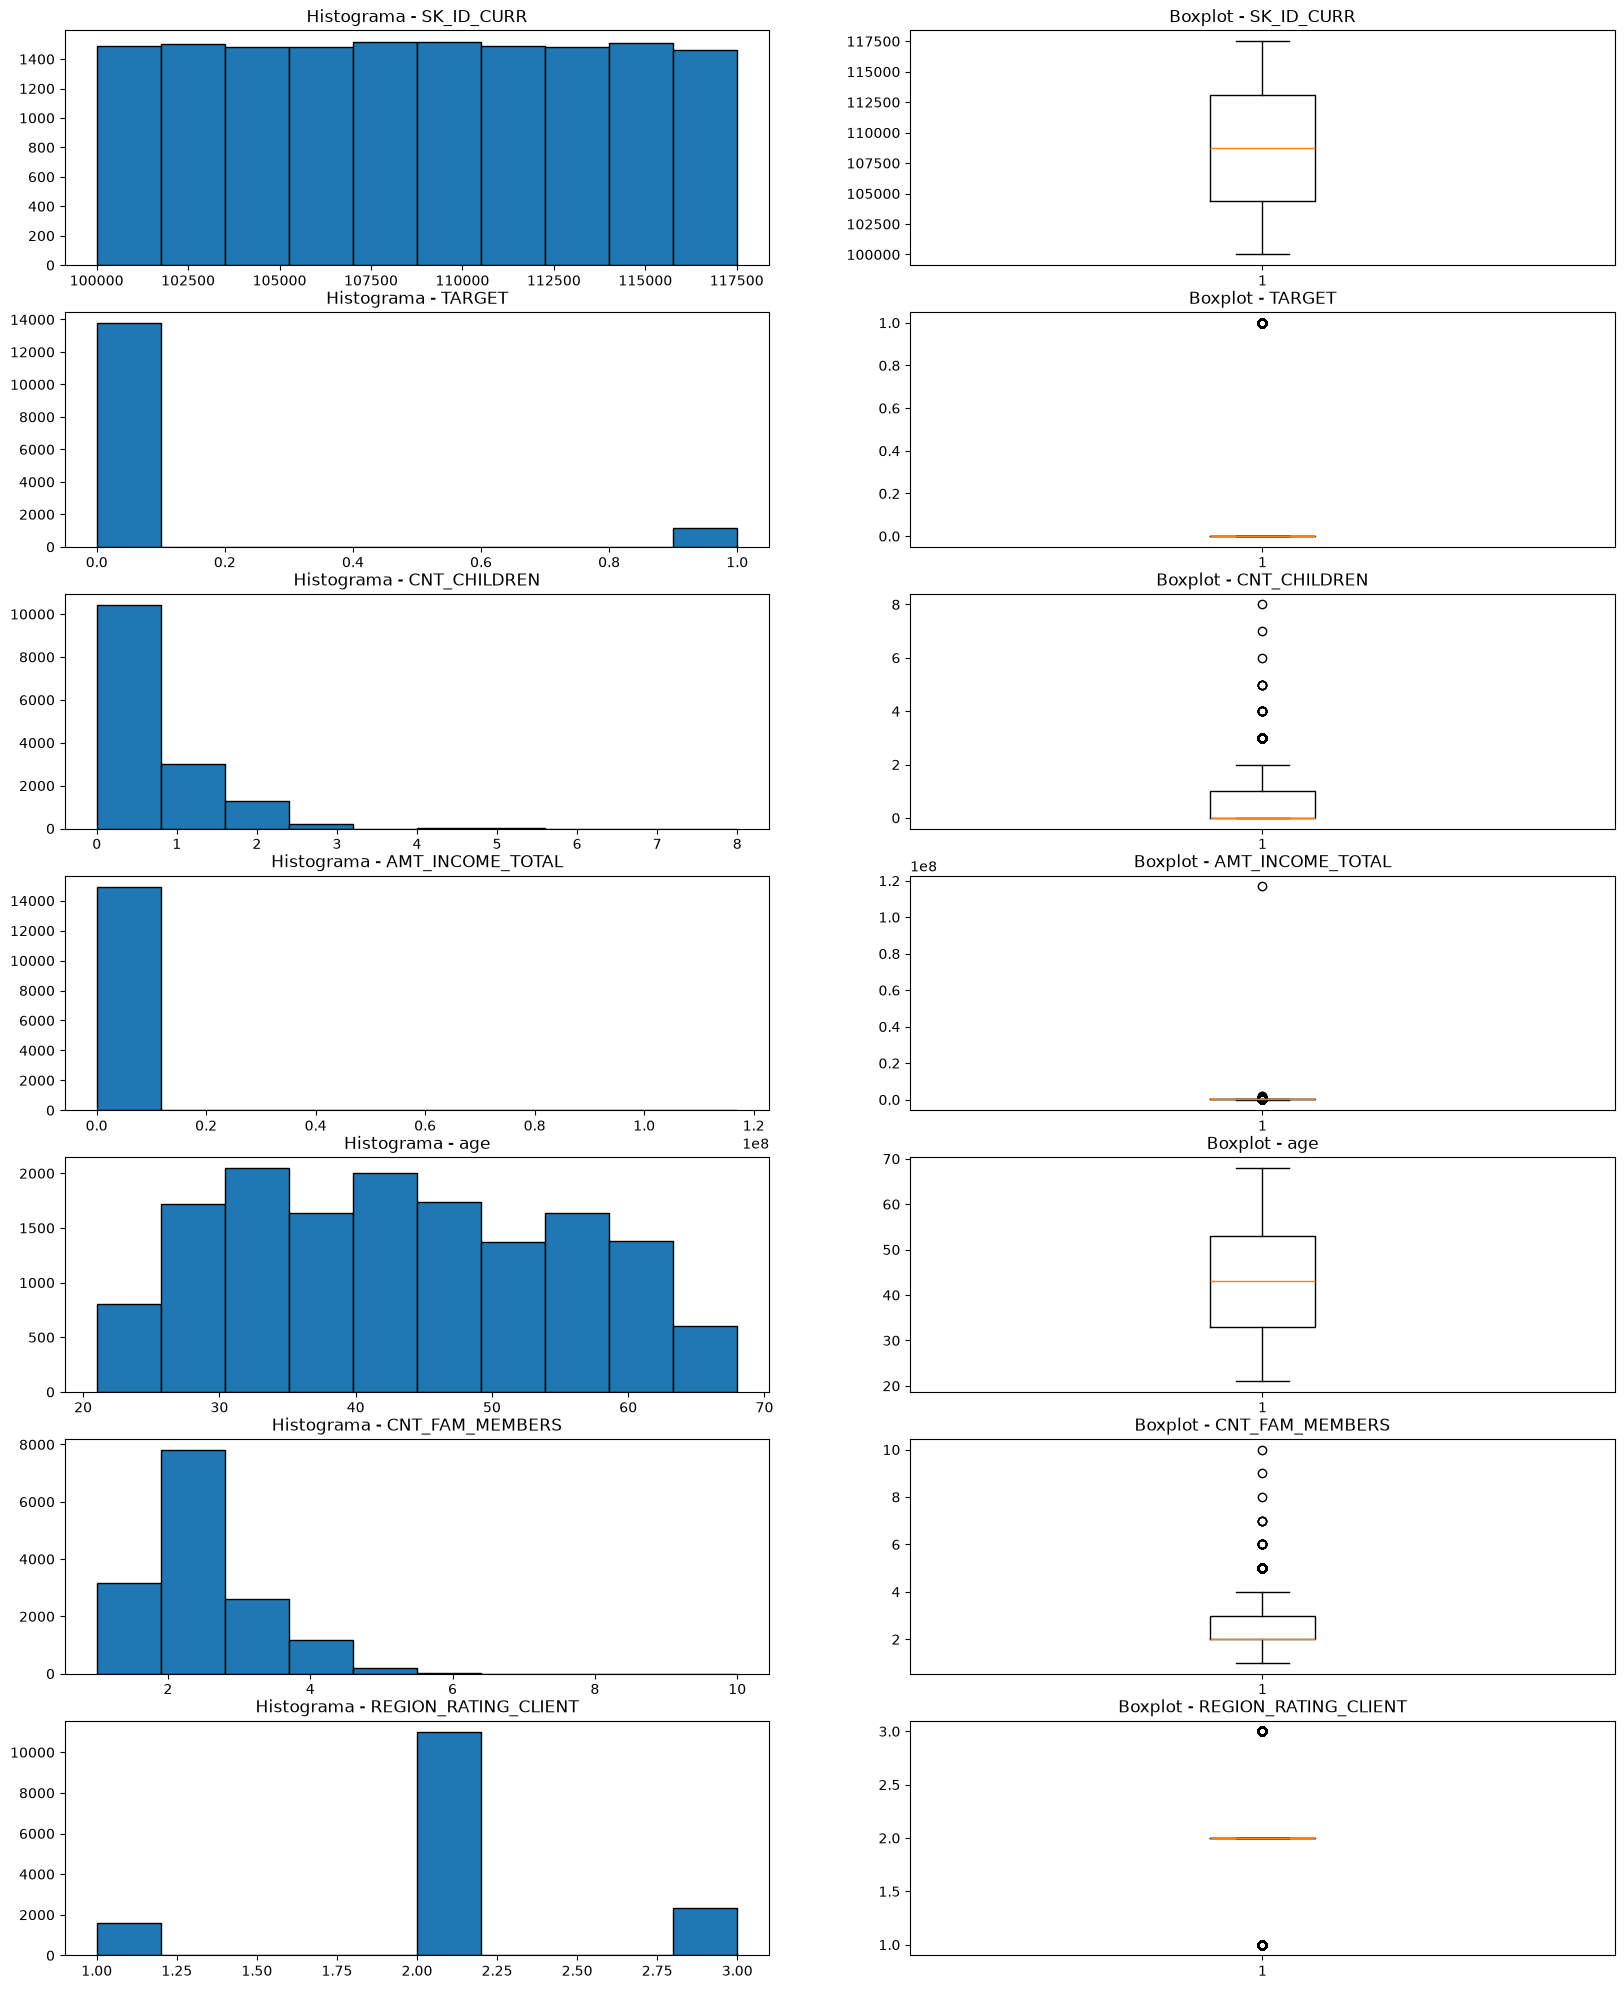

In [23]:
# verificando distribuiçoes dos dados 
fig, axes = plt.subplots(ncols=2, nrows=len(num_customers.columns), figsize=(20,25))
for i, num in enumerate(num_customers.columns): 
    axes[i, 0].hist(df_customers[num], edgecolor='black')
    axes[i, 0].set_title(f'Histograma - {num}')
    axes[i, 1].boxplot(df_customers[num])
    axes[i, 1].set_title(f'Boxplot - {num}') 

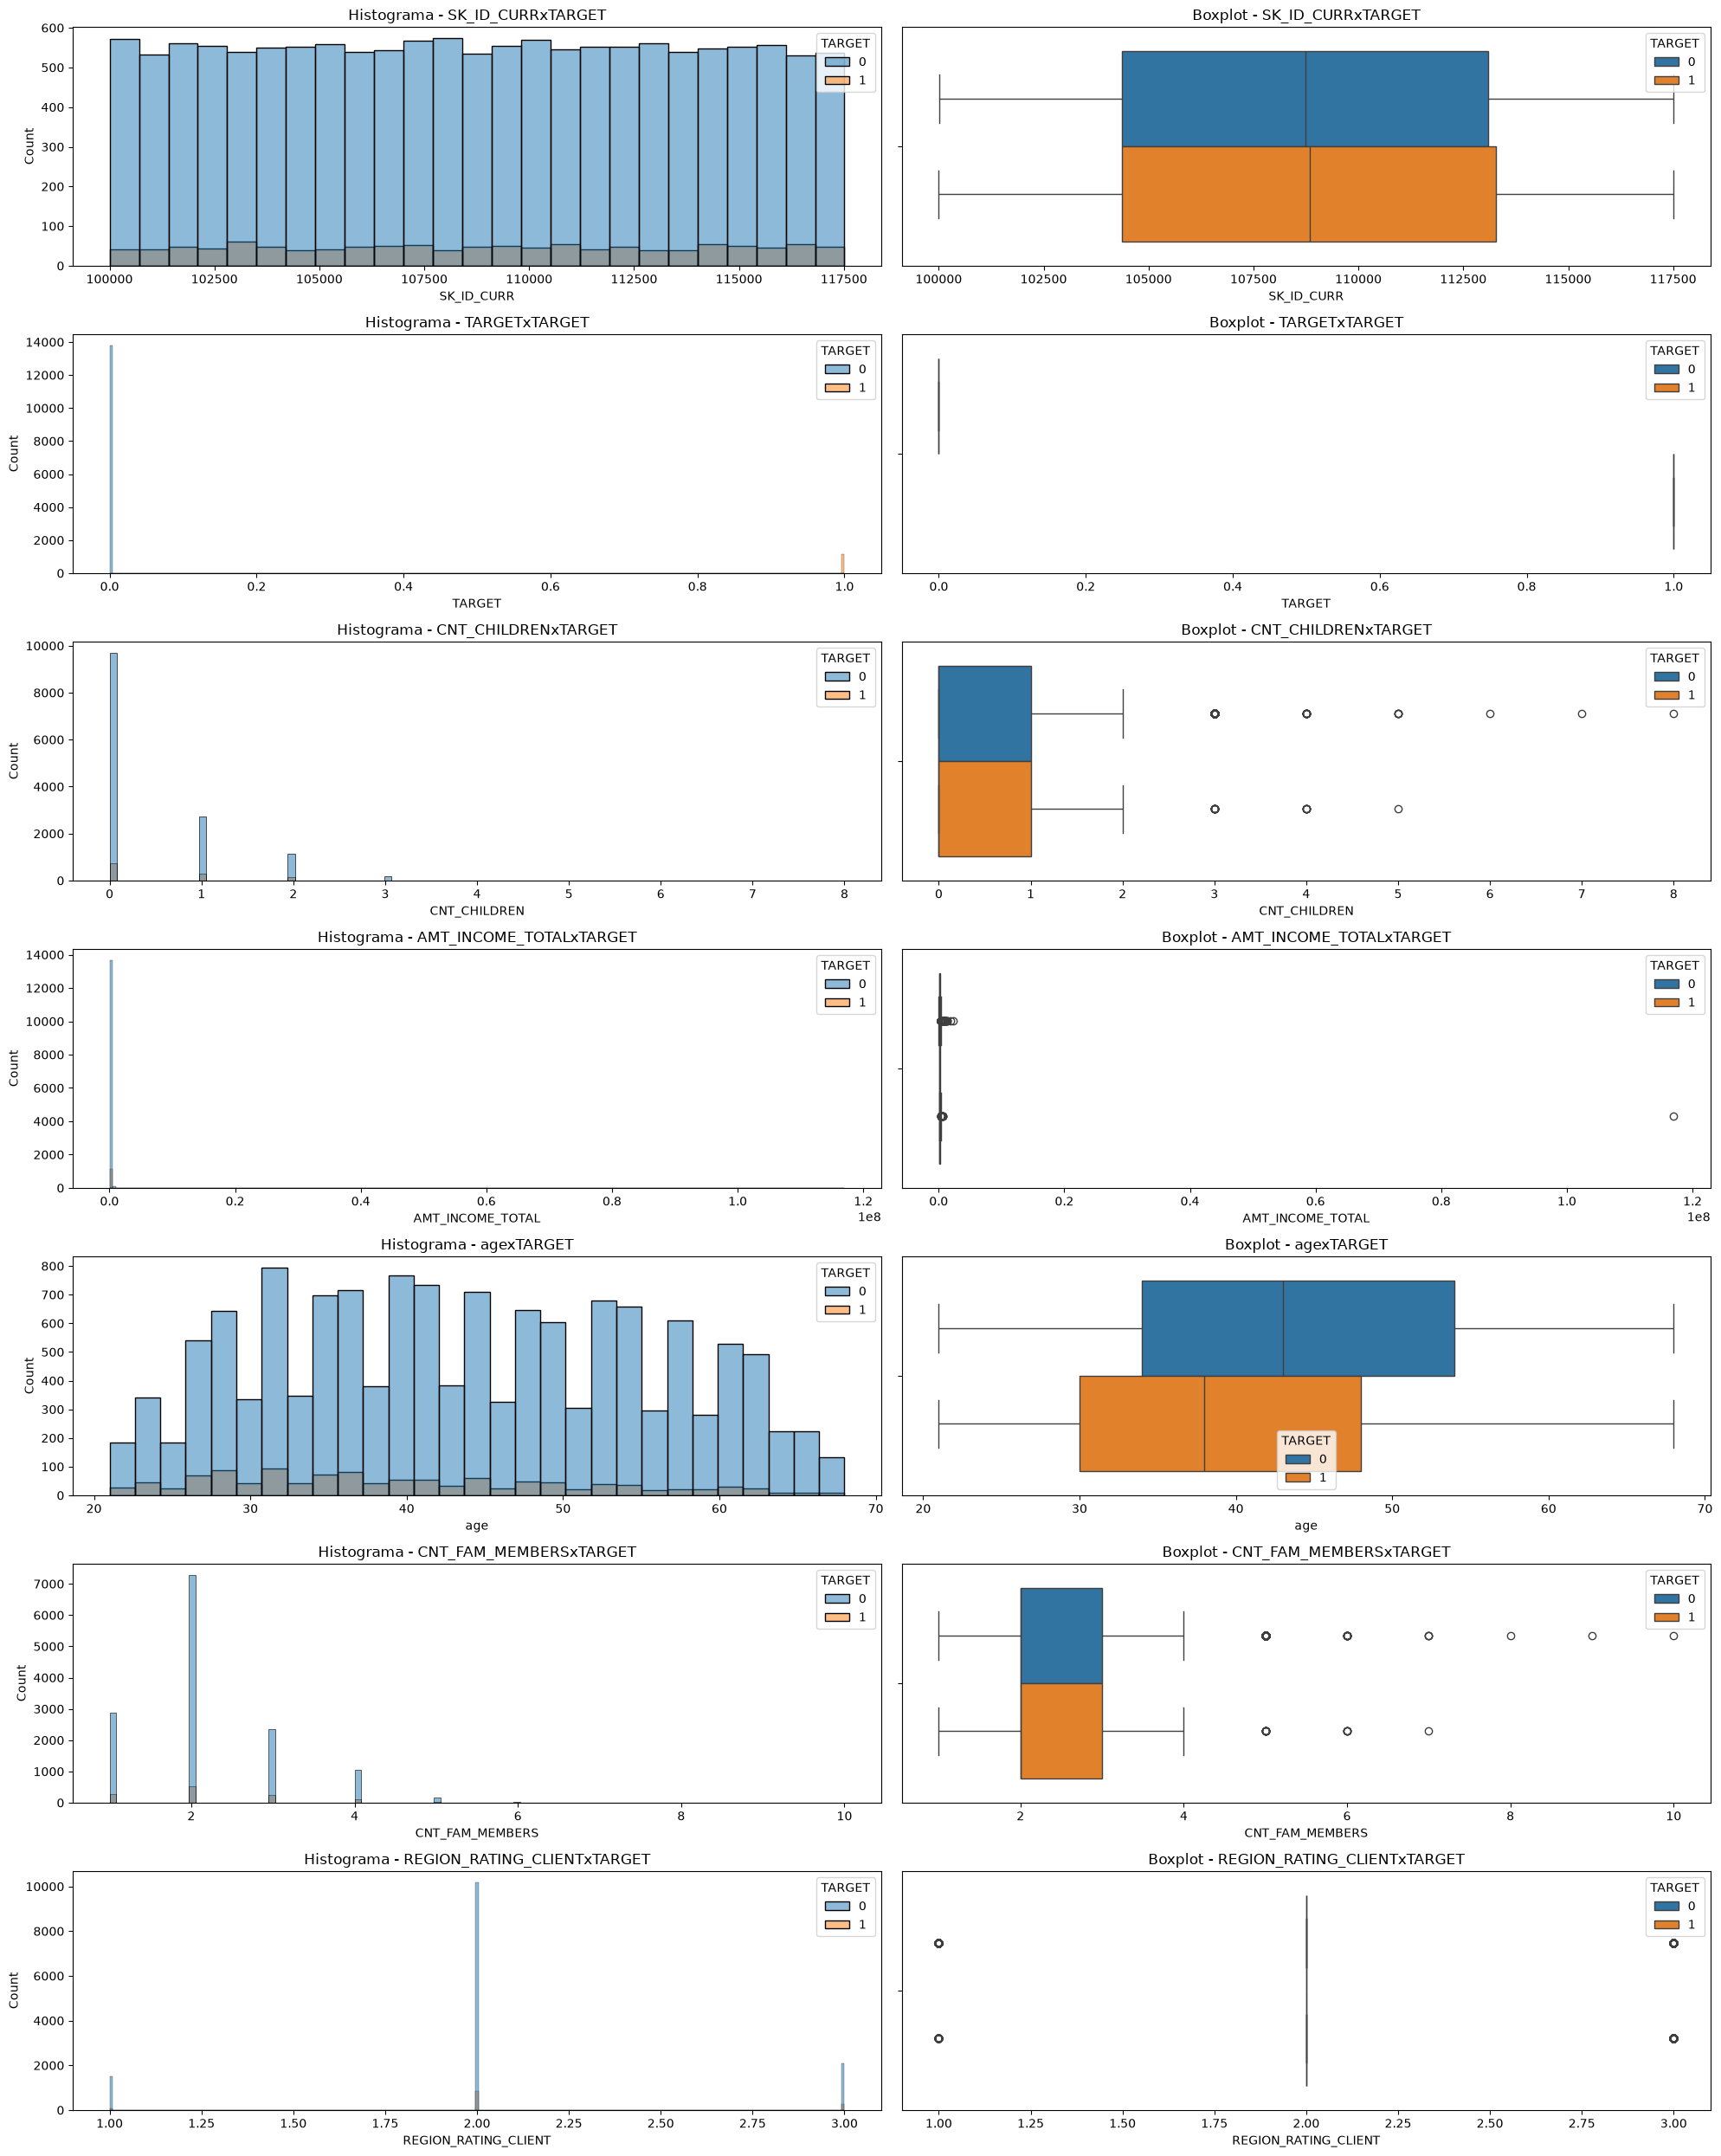

In [24]:
# verificando distribuiçao em relaçao ao target 
hist_plot(num_customers, 'TARGET')

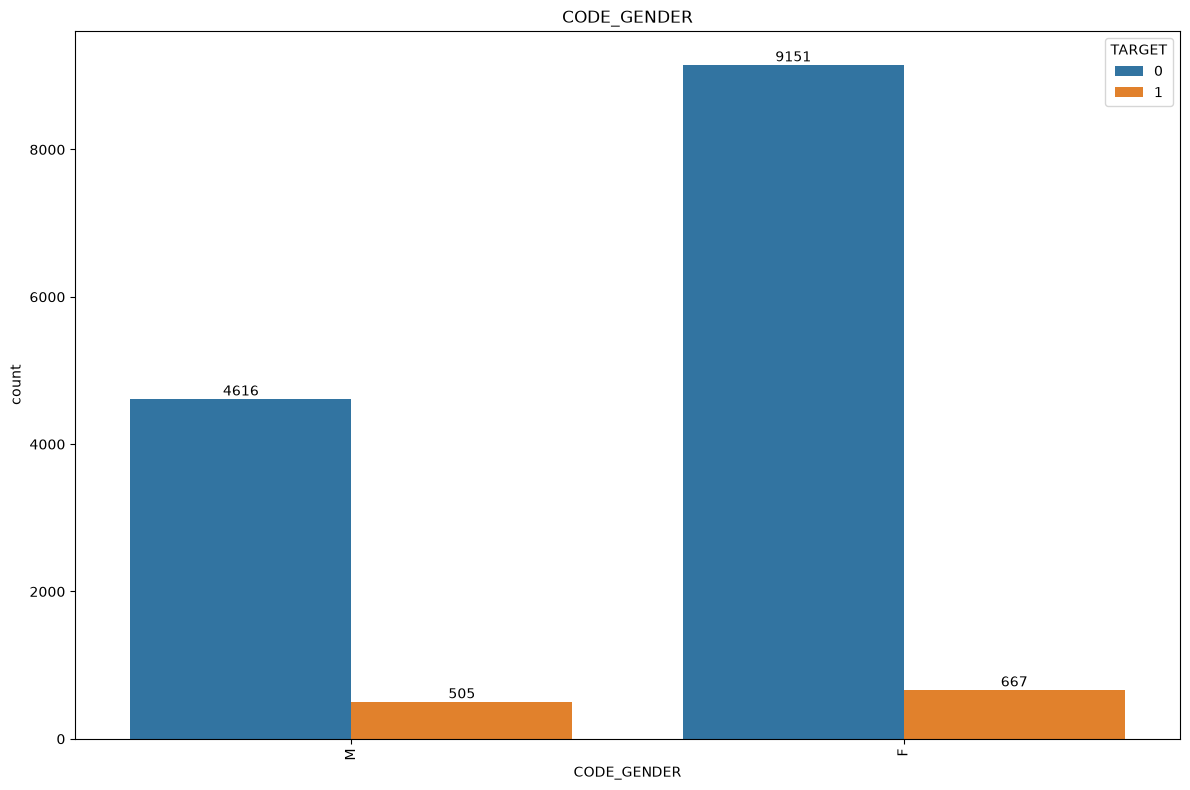

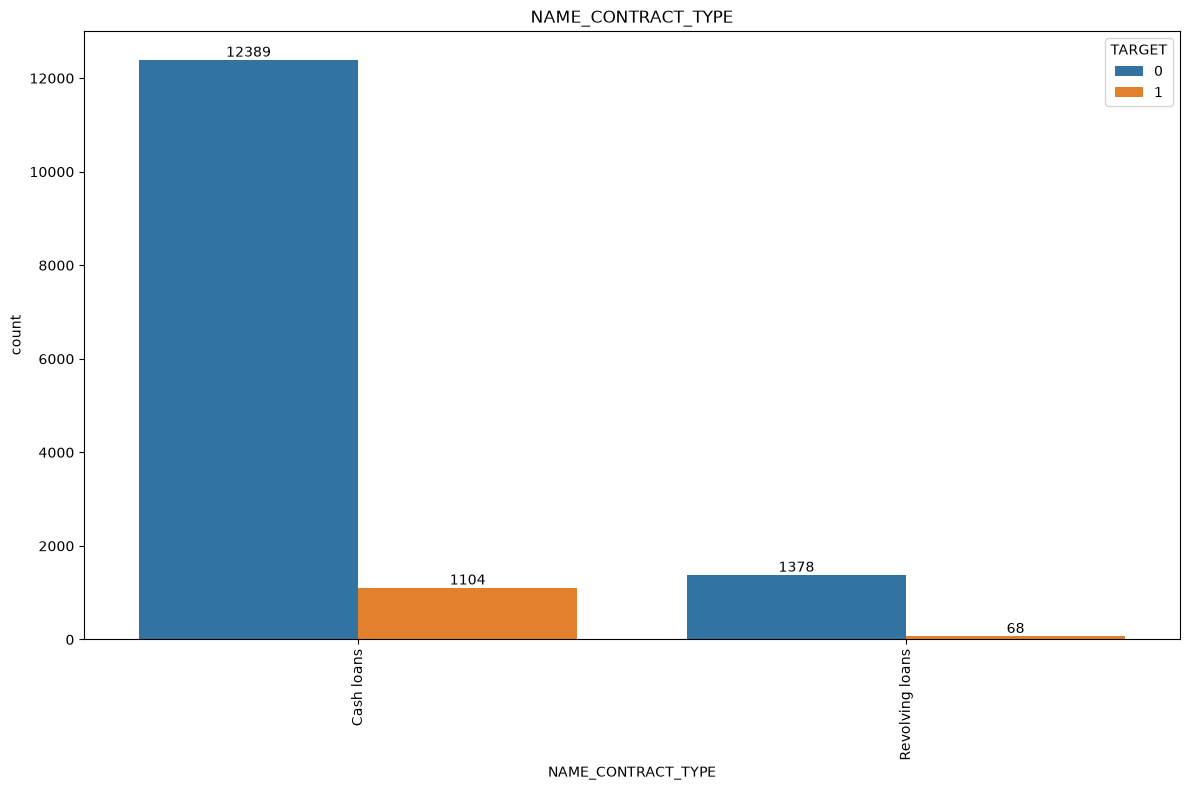

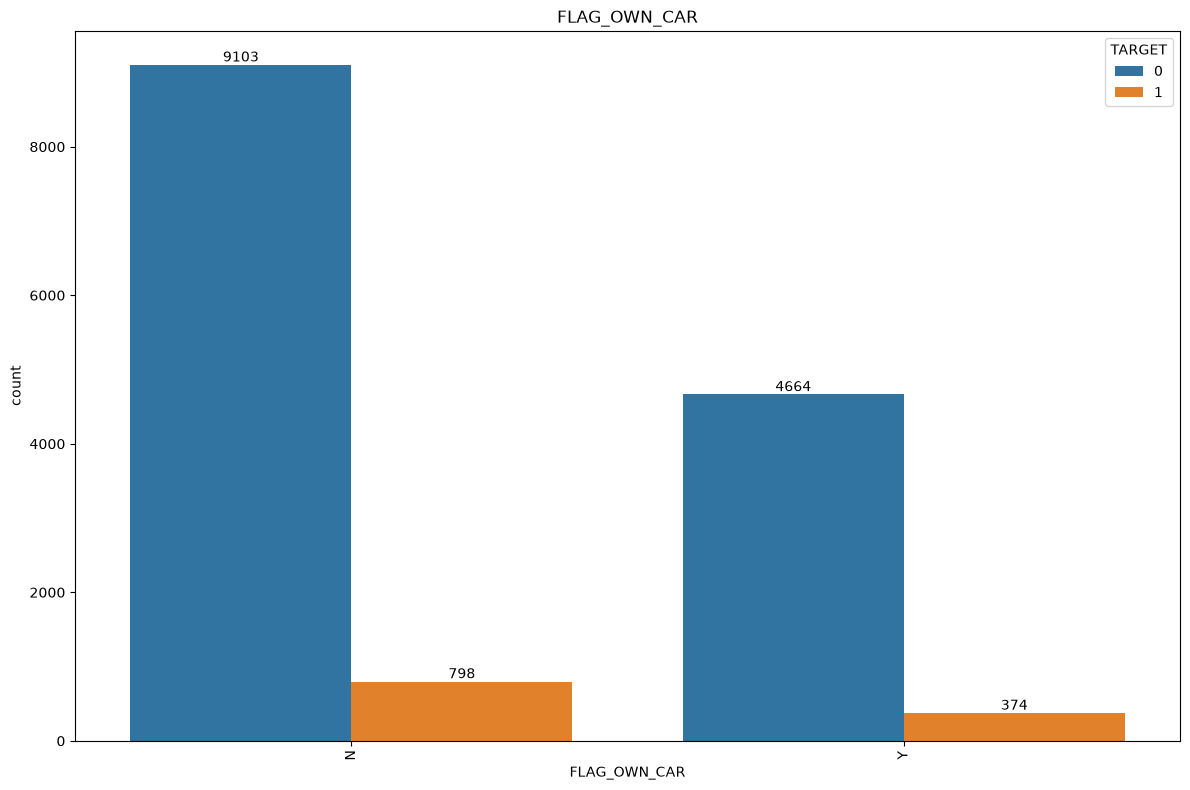

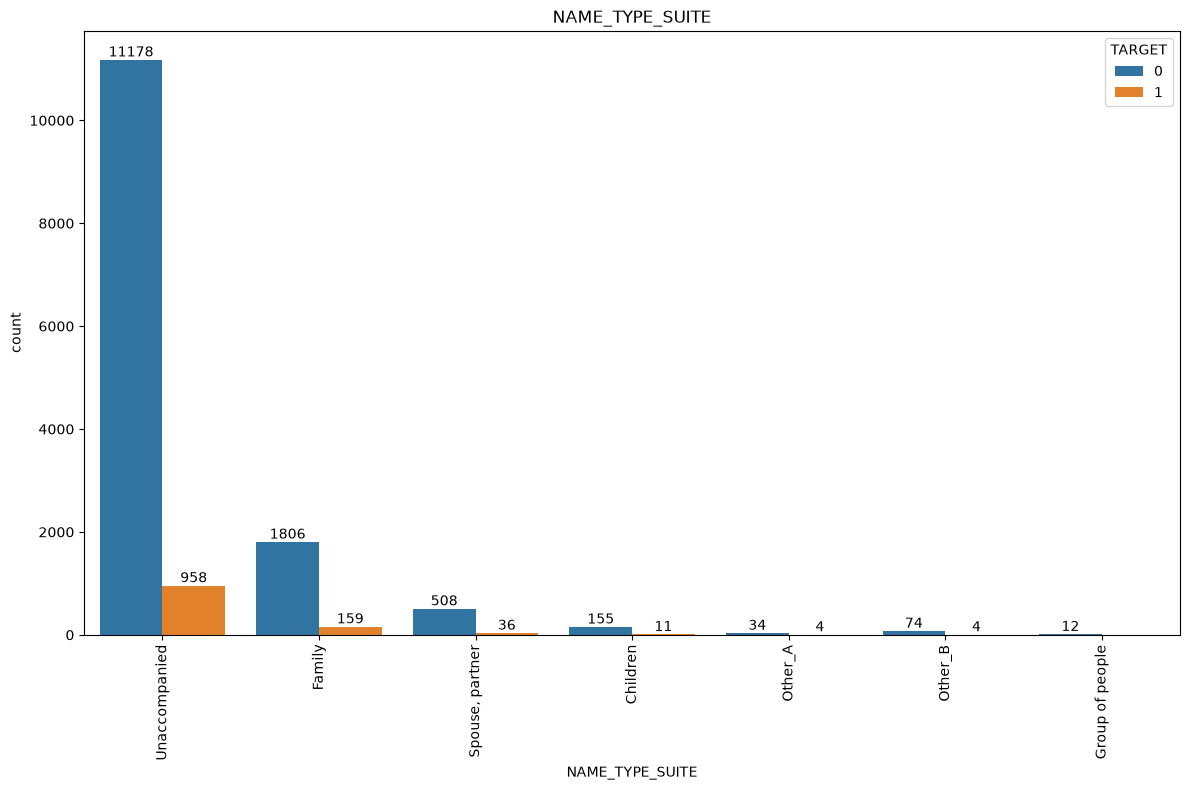

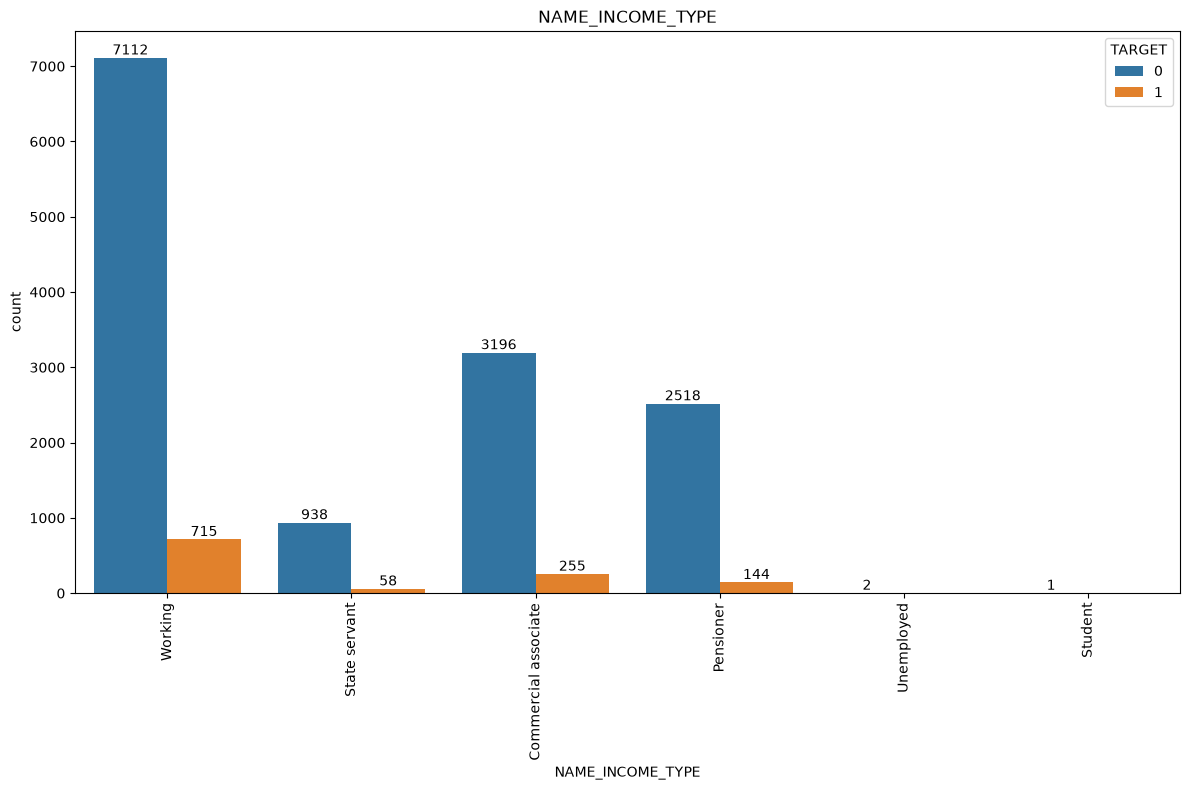

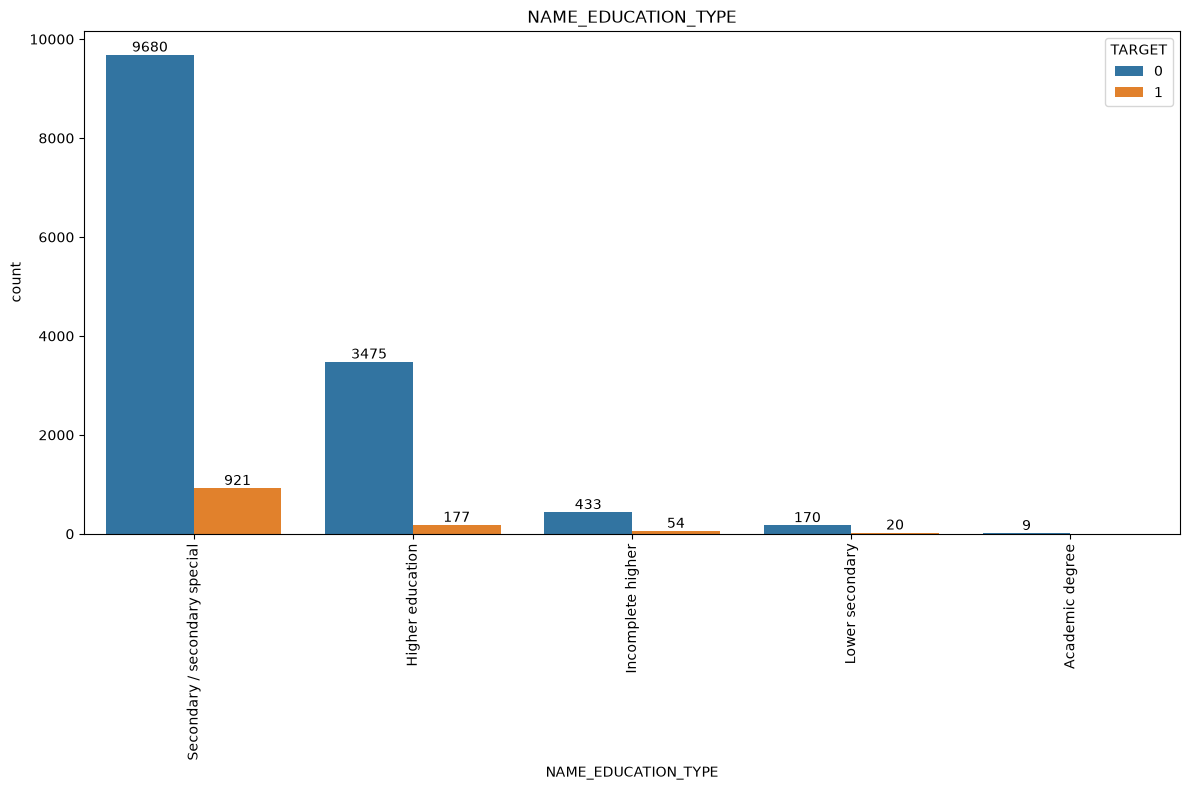

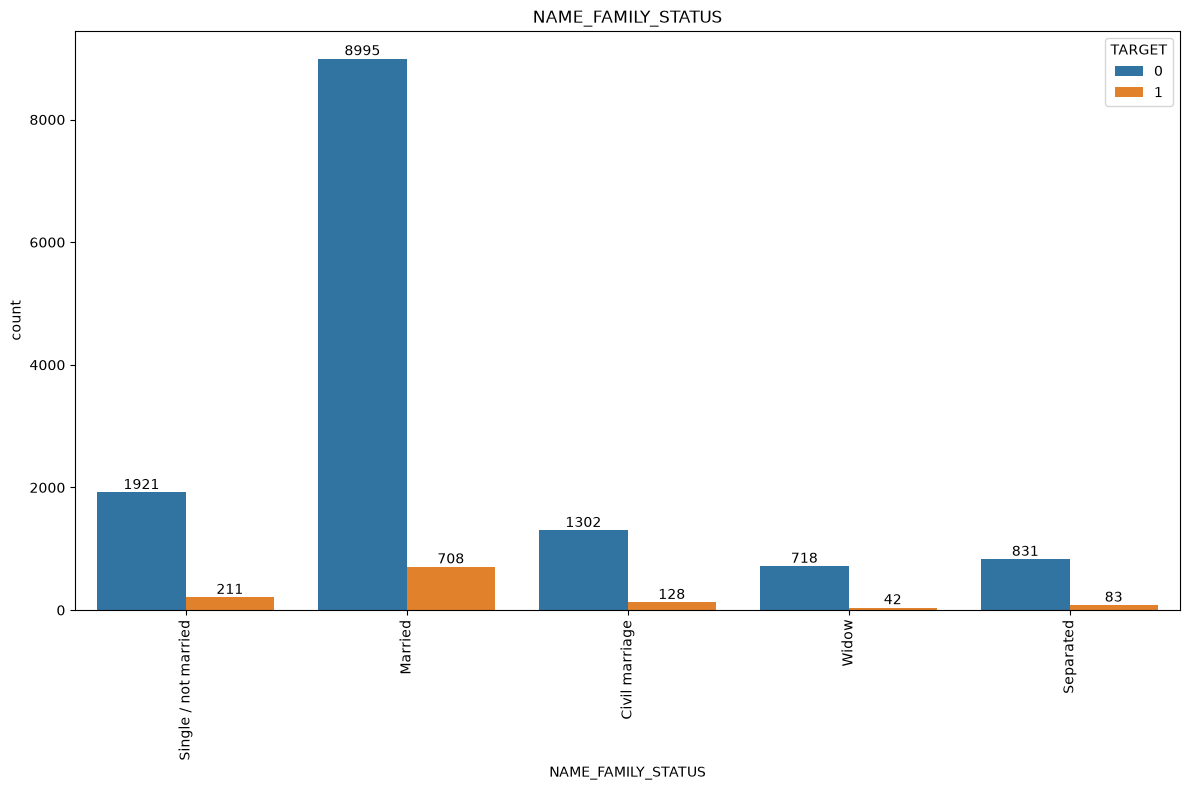

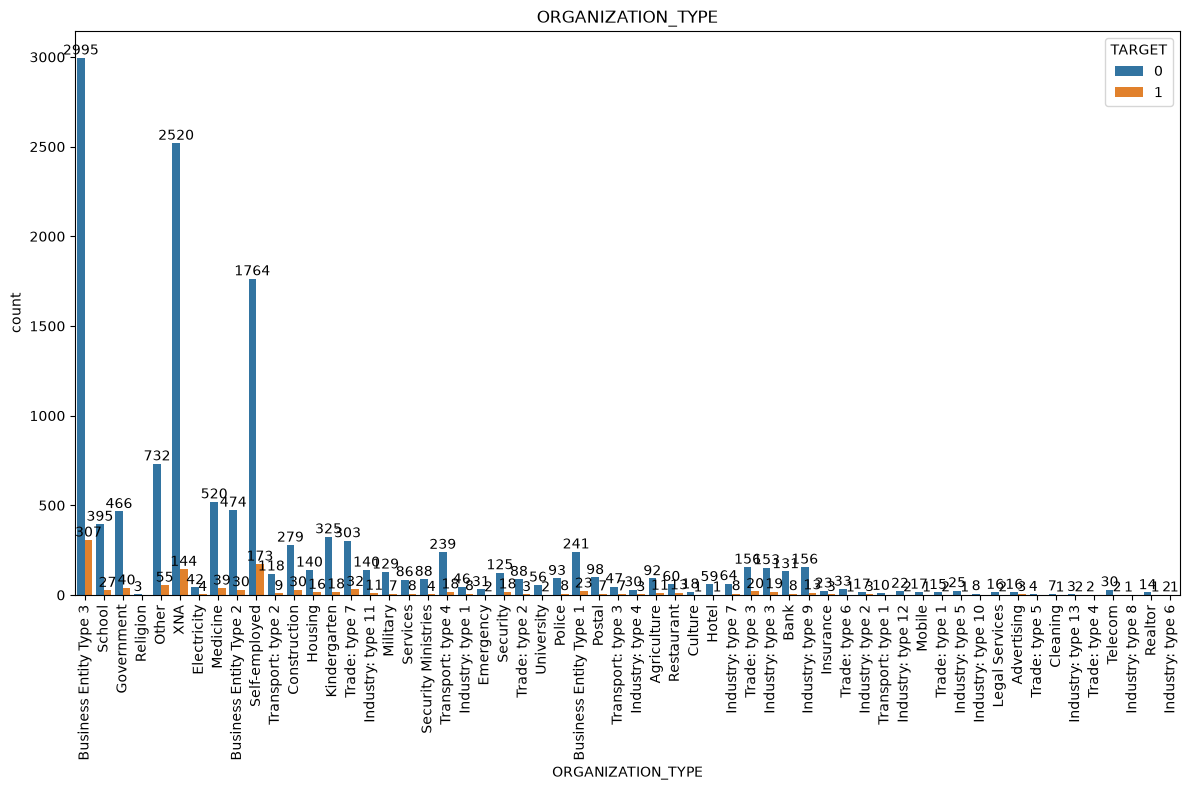

In [25]:
# verificando defaults em dados categoricos 
for cat in cat_customers:
    plt.figure(figsize=(12,8))
    plt.title(f'{cat}')
    ax = sns.countplot(data=df_customers, x=df_customers[cat], hue='TARGET')
    plt.xticks(rotation=90)
    for container in ax.containers:
        ax.bar_label(container, fontsize=10)
    plt.tight_layout()
    plt.show()

In [26]:
# verificando grau de formaçaio entre generos
plot_groupby(df_customers, 'CODE_GENDER', 'NAME_EDUCATION_TYPE', 'agg').agg_groupby('CODE_GENDER')

CODE_GENDER  NAME_EDUCATION_TYPE          
F            Academic degree                     7
             Higher education                 2489
             Incomplete higher                 303
             Lower secondary                   118
             Secondary / secondary special    6901
M            Academic degree                     2
             Higher education                 1163
             Incomplete higher                 184
             Lower secondary                    72
             Secondary / secondary special    3700
Name: CODE_GENDER, dtype: int64


desvio padrao: 0.061270721107528806
mediana: 0.43373032026069147
CODE_GENDER
F    0.390405
M    0.477055
Name: CNT_CHILDREN, dtype: float64


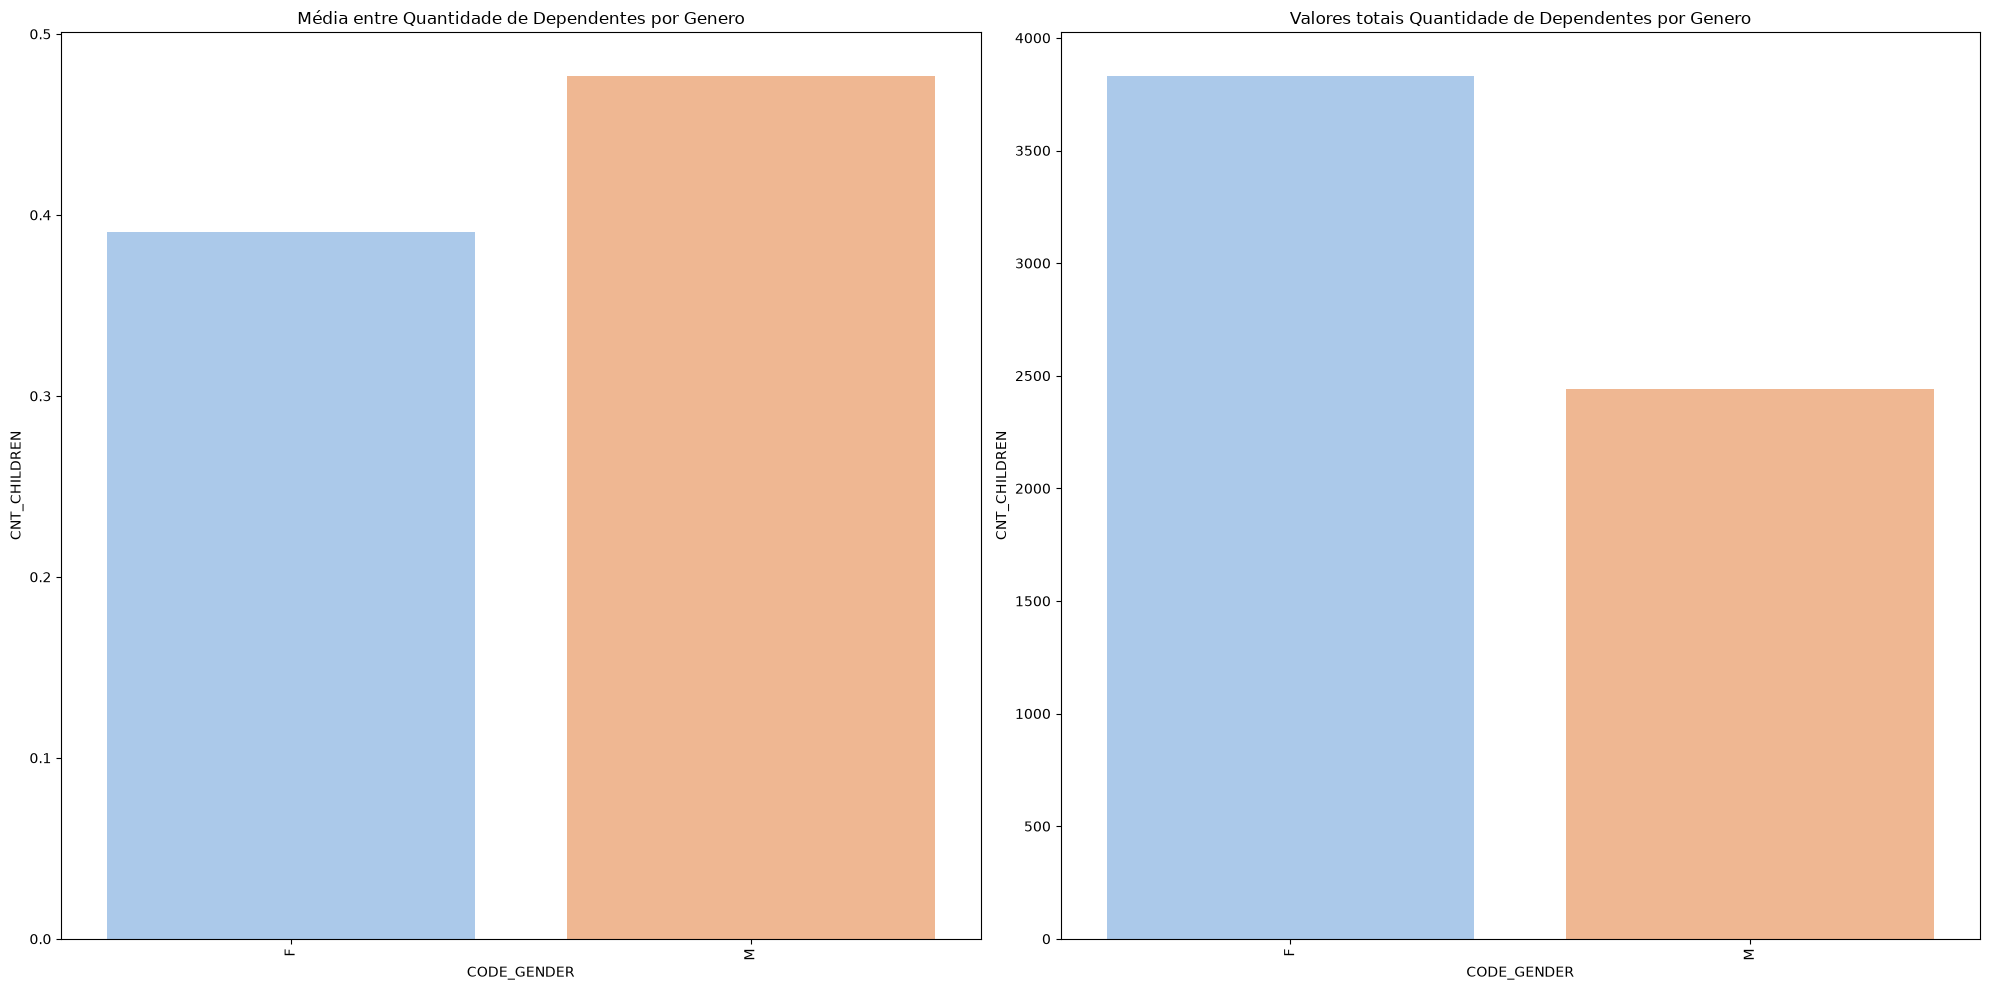

In [27]:
# verificando, por genero, quantidade de filhos 
plot_groupby(df_customers, 'CODE_GENDER', 'CNT_CHILDREN', 'Quantidade de Dependentes por Genero').plot_mean()

desvio padrao: 0.10478770415854952
mediana: 0.075
CNT_CHILDREN
0    0.071648
1    0.091120
2    0.100946
3    0.075000
4    0.315789
5    0.200000
6    0.000000
7    0.000000
8    0.000000
Name: TARGET, dtype: float64


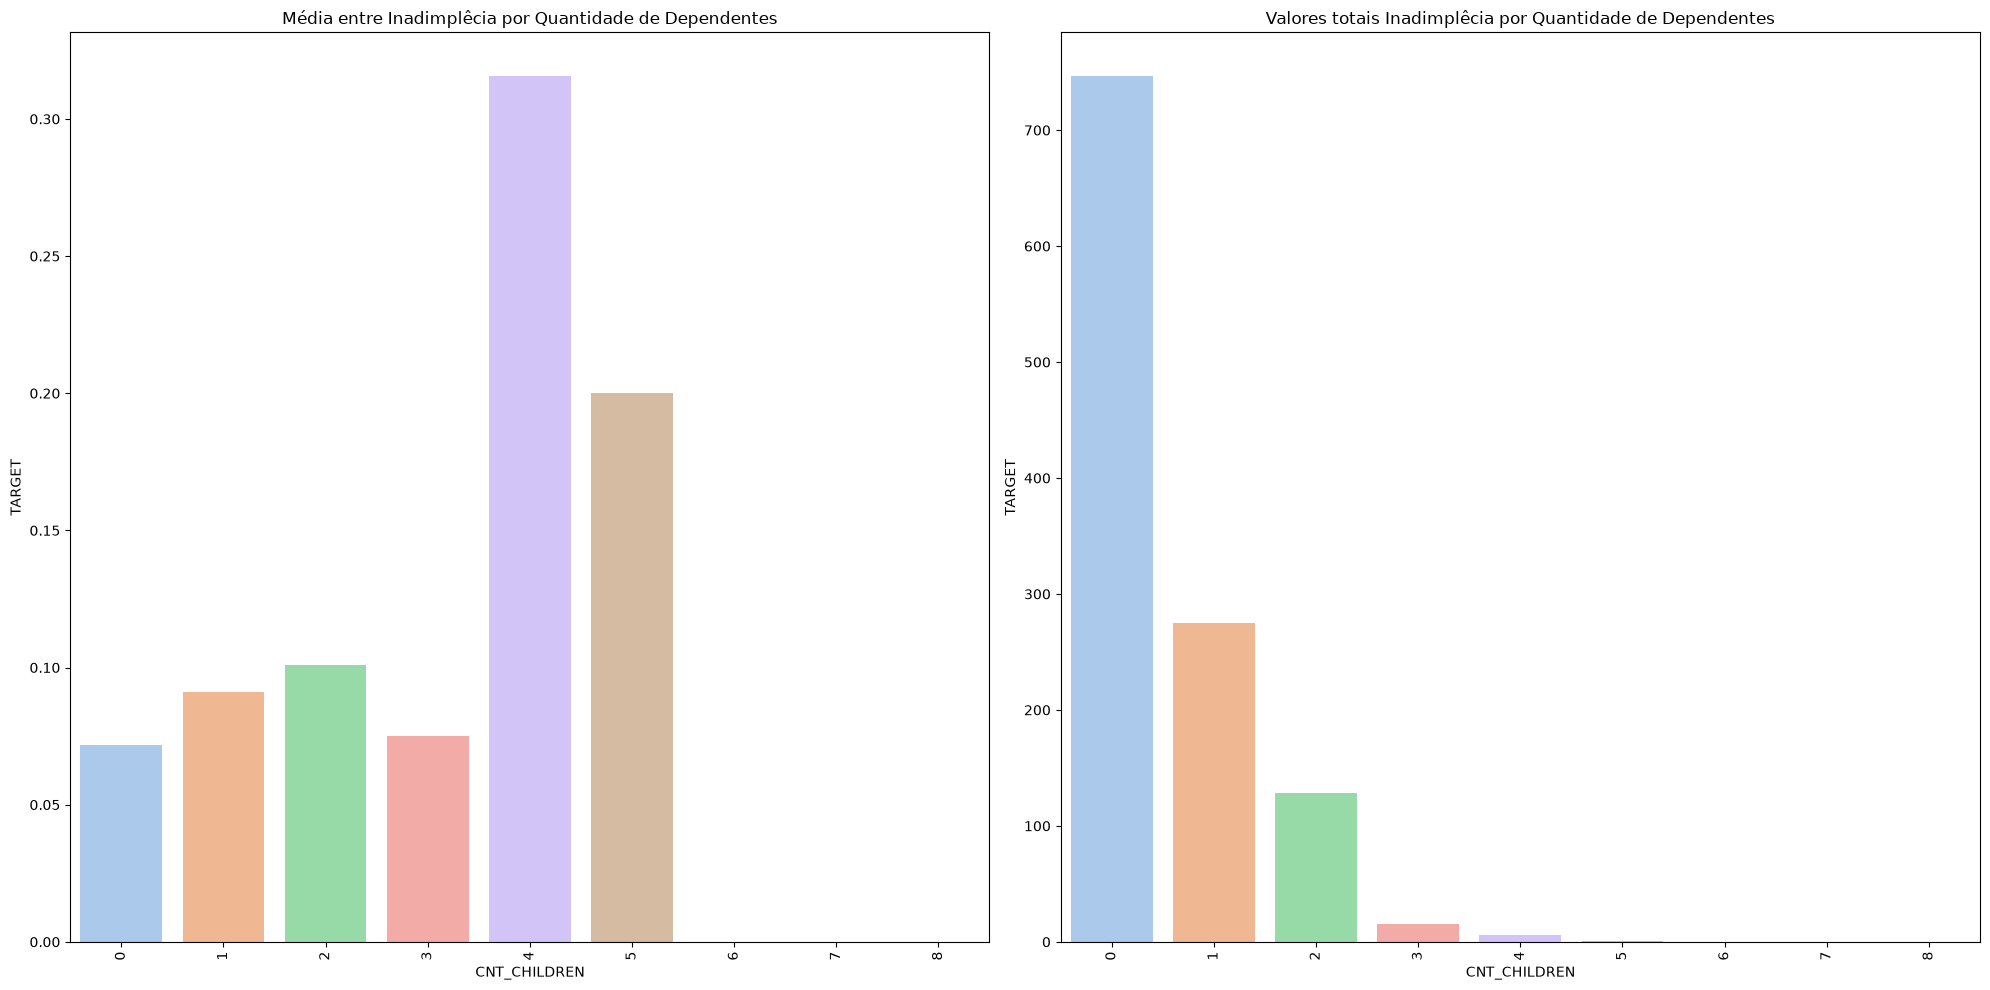

In [28]:
# verificando inadimplencia pela quantidade de dependentes 
plot_groupby(df_customers, 'CNT_CHILDREN', 'TARGET', 'Inadimplêcia por Quantidade de Dependentes').plot_mean()

In [ ]:
# verificando tipo de renda por genero 
plot_groupby(df_customers, 'NAME_INCOME_TYPE', 'CODE_GENDER', 'aa').agg_groupby('NAME_INCOME_TYPE')

NAME_INCOME_TYPE      CODE_GENDER
Commercial associate  F              2143
                      M              1308
Pensioner             F              2145
                      M               517
State servant         F               752
                      M               244
Student               M                 1
Unemployed            F                 2
Working               F              4776
                      M              3051
Name: NAME_INCOME_TYPE, dtype: int64
